In [79]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

O problema:

O Desenrola Brasil movimentou bilhões de reais em renegociações. Porém, essa atividade foi distribuída igualmente entre bancos e estados?

In [80]:
df = pd.read_csv('dados_desenrola.csv', sep=';')

print('Valores nulos:')
print(df.isna().sum())

print('\nDuplicados:')
print(df.duplicated().sum())

df['VOLUME_OPERACOES'] = (df['VOLUME_OPERACOES'].str.replace(',', '.', regex=False).astype(float))

Valores nulos:
DATA_BASE                       0
TIPO_DESENROLA                  0
UNIDADE_FEDERACAO               0
COD_CONGLOMERADO_FINANCEIRO     0
NOME_CONGLOMERADO_FINANCEIRO    0
NUMERO_OPERACOES                0
VOLUME_OPERACOES                0
dtype: int64

Duplicados:
0


Não foram identificados valores nulos em nenhuma das variáveis analisadas, e também não foram encontrados registros duplicados. Não foi necessária a aplicação de procedimentos adicionais de limpeza dos dados.

In [81]:
df_bancos = (df.groupby('NOME_CONGLOMERADO_FINANCEIRO')['VOLUME_OPERACOES'].sum().reset_index().sort_values(by='VOLUME_OPERACOES',ascending=False))

df_bancos.head(10)

,NOME_CONGLOMERADO_FINANCEIRO,VOLUME_OPERACOES
16,BRADESCO,1.859622e+09
67,SANTANDER,1.260149e+09
17,BRADESCO - PRUDENCIAL,7.952106e+08
63,ITAU,7.522152e+08
23,CAIXA ECONÔMICA FEDERAL,5.902124e+08
6,BB,5.356533e+08
66,NUBANK,4.746199e+08
19,BTG PACTUAL,4.403326e+08
61,INTER,2.450128e+08
24,CAIXA ECONÔMICA FEDERAL - PRUDENCIAL,2.006761e+08


In [82]:
top5 = df_bancos.head(5)['VOLUME_OPERACOES'].sum()

total = df_bancos['VOLUME_OPERACOES'].sum()

participacao = top5 / total * 100

print(f'{participacao:.2f}%')

68.97%


Os cinco maiores conglomerados financeiros concentraram aproximadamente 69% do volume renegociado do programa Desenrola Brasil. Isso indican uma forte concentração das operações entre poucas instituições.

In [83]:
df_estados = (df.groupby('UNIDADE_FEDERACAO')['VOLUME_OPERACOES'].sum().reset_index().sort_values(by='VOLUME_OPERACOES',ascending=False))

df_estados.head(10)

,UNIDADE_FEDERACAO,VOLUME_OPERACOES
25,SP,2.431235e+09
18,RJ,7.899351e+08
10,MG,5.947894e+08
17,PR,4.346896e+08
4,BA,3.774432e+08
22,RS,3.555811e+08
23,SC,3.099692e+08
15,PE,2.594012e+08
5,CE,2.401199e+08
8,GO,2.331022e+08


In [84]:
df_ticket = (df.groupby('NOME_CONGLOMERADO_FINANCEIRO')[['VOLUME_OPERACOES', 'NUMERO_OPERACOES']].sum())

df_ticket['TICKET_MEDIO'] = (df_ticket['VOLUME_OPERACOES']/df_ticket['NUMERO_OPERACOES'])

df_ticket.sort_values(by='TICKET_MEDIO',ascending=False).head(10)

,VOLUME_OPERACOES,NUMERO_OPERACOES,TICKET_MEDIO
NOME_CONGLOMERADO_FINANCEIRO,,,
BRADESCO - PRUDENCIAL,7.952106e+08,8165,97392.599301
BCO DO NORDESTE DO BRASIL S.A.,2.654186e+06,125,21233.487840
BCO DO NORDESTE DO BRASIL S.A. - PRUDENCIAL,1.757345e+07,870,20199.372851
BRADESCO,1.859622e+09,126841,14661.044382
BB - PRUDENCIAL,2.354127e+06,245,9608.683143
BCO DO EST. DO PA S.A.,9.250258e+05,125,7400.206000
BCO DO EST. DE SE S.A.,1.404229e+06,230,6105.345478
BANCO C6 - PRUDENCIAL,3.305262e+06,576,5738.302708
VOTORANTIM,1.322538e+08,27120,4876.613708


In [85]:
df_ticket_estado = (df.groupby('UNIDADE_FEDERACAO')[['VOLUME_OPERACOES','NUMERO_OPERACOES']].sum())

df_ticket_estado['TICKET_MEDIO'] = (df_ticket_estado['VOLUME_OPERACOES']/df_ticket_estado['NUMERO_OPERACOES'])

In [86]:
volume_array = np.array(df_bancos['VOLUME_OPERACOES'], dtype=float)

media = np.mean(volume_array)
mediana = np.median(volume_array)

q1 = np.percentile(volume_array, 25)
q2 = np.percentile(volume_array, 50)
q3 = np.percentile(volume_array, 75)

assimetria = pd.Series(volume_array).skew()
curtose = pd.Series(volume_array).kurt()
mediana = np.median(volume_array)

q1 = np.percentile(volume_array, 25)
q2 = np.percentile(volume_array, 50)
q3 = np.percentile(volume_array, 75)

assimetria = pd.Series(volume_array).skew()
curtose = pd.Series(volume_array).kurt()

iqr = q3 - q1

limiteInferior = q1 - 1.5 * iqr
limiteSuperior = q3 + 1.5 * iqr

outliersBancos = df_bancos[df_bancos['VOLUME_OPERACOES'] > limiteSuperior
]

print("Média:", media)
print("Mediana:", mediana)
print("Assimetria:", assimetria)
print("Curtose:", curtose)
print("Limite Inferior:", limiteInferior)
print("Limite Superior:", limiteSuperior)
print("IQR:", iqr)


Média: 100303393.39105262
Mediana: 37794.59
Assimetria: 4.051356283967517
Curtose: 18.647387101628897
Limite Inferior: -5695824.061249999
Limite Superior: 9515190.16875
IQR: 3802753.5575


Assimetria alta: A maioria dos bancos possui volumes relativamente baixos ou médios, enquanto poucos bancos concentram volumes extremamente elevados.

Curtose alta: Existem observações muito distantes do centro da distribuição.

In [87]:
df_bancos_outliers_inferiores = df_bancos[df_bancos['VOLUME_OPERACOES'] < limiteInferior]

df_bancos_outliers_superiores = df_bancos[df_bancos['VOLUME_OPERACOES'] > limiteSuperior]


if df_bancos_outliers_inferiores.empty:
    print('Não há outliers inferiores')
else:
    print(df_bancos_outliers_inferiores.sort_values(by='VOLUME_OPERACOES',ascending=True))


if df_bancos_outliers_superiores.empty:
    print('Não há outliers superiores')
else:
    print(df_bancos_outliers_superiores.sort_values(by='VOLUME_OPERACOES',ascending=False))

Não há outliers inferiores
                   NOME_CONGLOMERADO_FINANCEIRO  VOLUME_OPERACOES
16                                     BRADESCO      1.859622e+09
67                                    SANTANDER      1.260149e+09
17                        BRADESCO - PRUDENCIAL      7.952106e+08
63                                         ITAU      7.522152e+08
23                      CAIXA ECONÔMICA FEDERAL      5.902124e+08
6                                            BB      5.356533e+08
66                                       NUBANK      4.746199e+08
19                                  BTG PACTUAL      4.403326e+08
61                                        INTER      2.450128e+08
24         CAIXA ECONÔMICA FEDERAL - PRUDENCIAL      2.006761e+08
74                                   VOTORANTIM      1.322538e+08
64                            ITAU - PRUDENCIAL      1.157199e+08
14                                          BMG      6.750141e+07
22                                      C6 BANK  

A distribuição do volume renegociado não foi igual entre todas as instituições. Algumas apresentaram um volume muito superior ao resto da amostra, sendo classificadas como outliers pelo método IQR. No entanto, esses outliers são todos superiores, e não têm nenhum outlier inferior nessas amostras, ou seja, não existem bancos com volume renegociado extremamente baixo em comparação ao resto da distribuição.

In [88]:
df['DATA_BASE'] = pd.to_datetime(df['DATA_BASE'].astype(str),format='%Y%m')

df_tempo = (df.groupby('DATA_BASE')['VOLUME_OPERACOES'].sum().reset_index())

df_tempo 

,DATA_BASE,VOLUME_OPERACOES
0,2023-09-01,1.231593e+09
1,2023-10-01,4.929996e+08
2,2023-11-01,6.083984e+08
3,2023-12-01,4.724228e+08
4,2024-01-01,1.953478e+08
5,2024-02-01,2.230105e+08
6,2024-03-01,3.286023e+08
7,2024-04-01,2.401843e+08
8,2024-05-01,2.983204e+08
9,2024-06-01,4.977472e+08


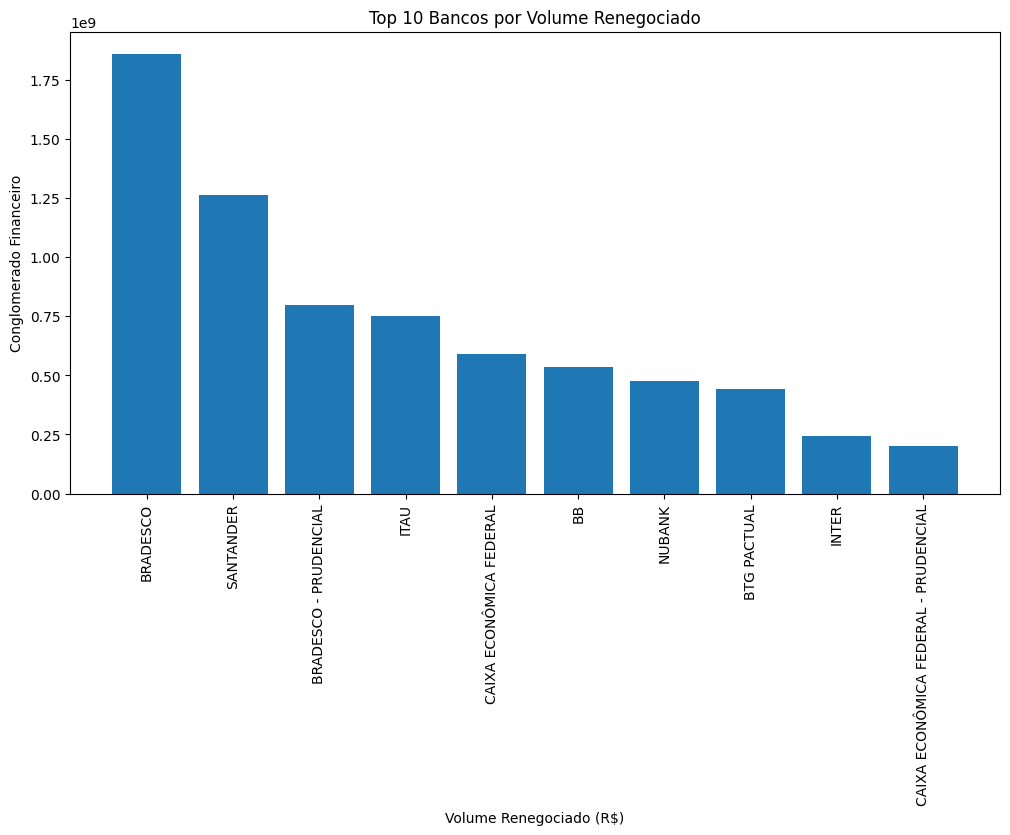

In [89]:
plt.figure(figsize=(12,6))

plt.bar(df_bancos.head(10)['NOME_CONGLOMERADO_FINANCEIRO'],df_bancos.head(10)['VOLUME_OPERACOES'])

plt.xticks(rotation=90)
plt.title('Top 10 Bancos por Volume Renegociado')

plt.xlabel('Volume Renegociado (R$)')
plt.ylabel('Conglomerado Financeiro')

plt.show()

O maior outlier aparenta ser o banco Bradesco, e logo após ele, o banco Santander.

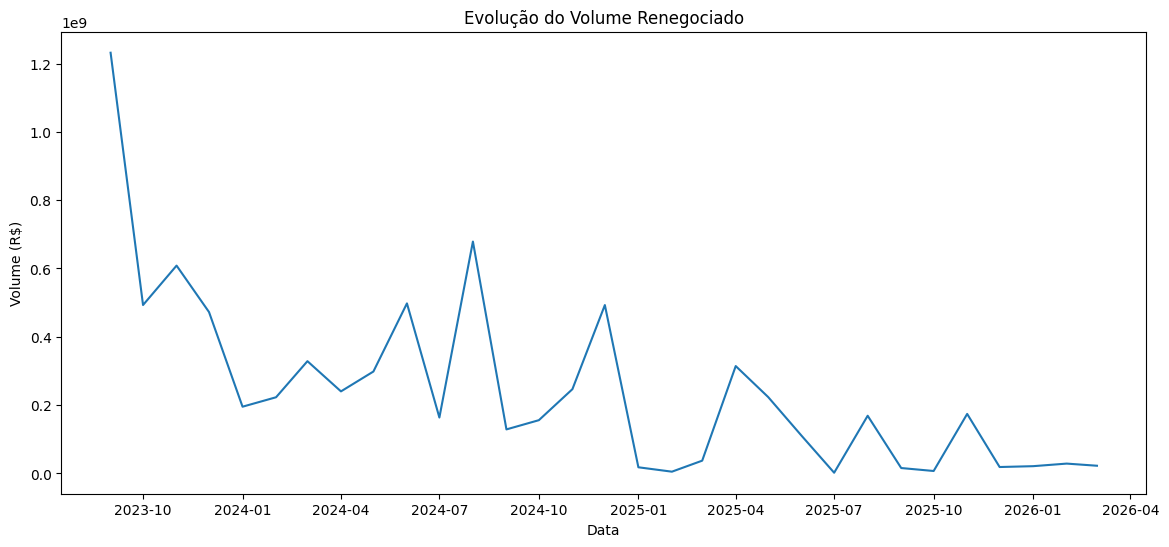

In [90]:
plt.figure(figsize=(14,6))

plt.plot(df_tempo['DATA_BASE'],df_tempo['VOLUME_OPERACOES'])

plt.title('Evolução do Volume Renegociado')
plt.xlabel('Data')
plt.ylabel('Volume (R$)')


plt.show()

Foi visto um maior volume renegociado no início da série, em setembro de 2023, com aproximadamente R$ 1,23 bilhão. Entretanto, nos meses seguintes nós observamos uma redução muito grande no volume, com alguns períodos de recuperação, que acontecem especialmente em agosto e dezembro de 2024.

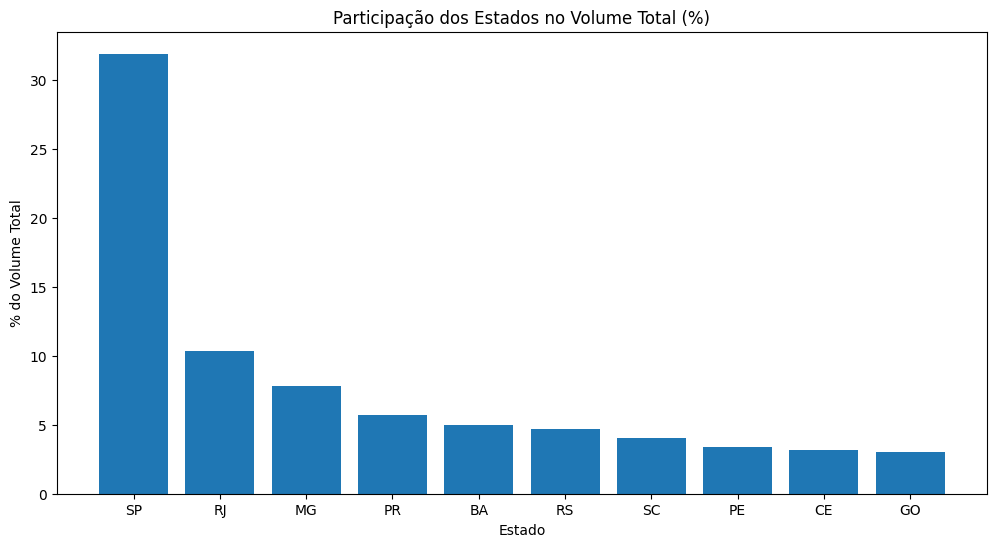

In [91]:
total = df_estados['VOLUME_OPERACOES'].sum()

df_estados['PARTICIPACAO_%'] = (df_estados['VOLUME_OPERACOES'] / total * 100)

df_estados.head(10)

plt.figure(figsize=(12,6))

plt.bar(df_estados.head(10)['UNIDADE_FEDERACAO'],df_estados.head(10)['PARTICIPACAO_%']
)

plt.title('Participação dos Estados no Volume Total (%)')
plt.xlabel('Estado')
plt.ylabel('% do Volume Total')

plt.show()

Como esperado: os três estados do Sudeste: São Paulo, Rio de Janeiro e Minas Gerais; dominam em participação, com destaque para São Paulo, o grande "polo" do mercado financeiro latino-americano. 

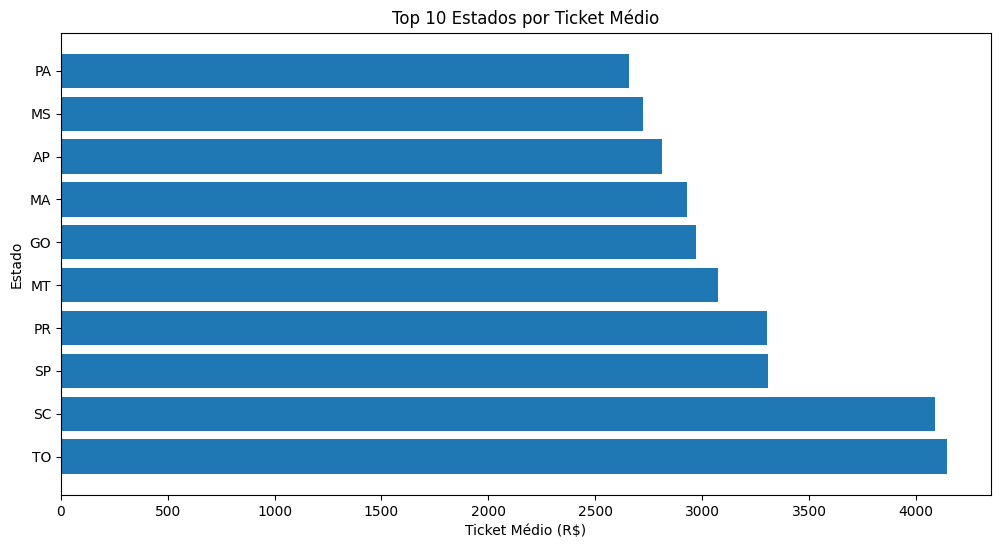

In [92]:
top10_estados = (df_ticket_estado.sort_values(by='TICKET_MEDIO', ascending=False).head(10))
plt.figure(figsize=(12,6))

plt.barh(top10_estados.index,top10_estados['TICKET_MEDIO'])

plt.title('Top 10 Estados por Ticket Médio')
plt.xlabel('Ticket Médio (R$)')
plt.ylabel('Estado')

plt.show()

Estados como Tocantins, Santa Catarina e São Paulo apresentaram os maiores tickets médios, o que indica que suas renegociações envolveram valores médios maiores por operação.

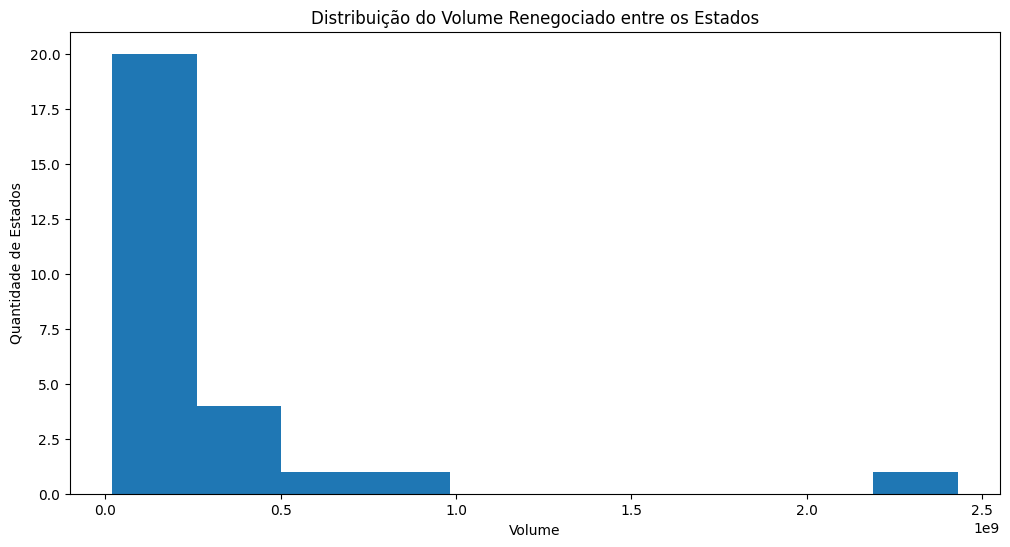

In [93]:
plt.figure(figsize=(12,6))

plt.hist(df_estados['VOLUME_OPERACOES'],bins=10)

plt.title('Distribuição do Volume Renegociado entre os Estados')

plt.xlabel('Volume')
plt.ylabel('Quantidade de Estados')

plt.show()

O volume renegociado apresentou forte assimetria entre os estados brasileiros, com poucos estados concentrando grande parcela dos recursos movimentados.